<a href="https://colab.research.google.com/github/jhonathanwesley/machine_learning/blob/main/core/ROIPredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning para prever ROI
> Dataset:

- [Vendas de Liquor em Iowa](https://data.iowa.gov/Sales-Distribution/Iowa-Liquor-Sales/m3tr-qhgy/about_data)

> Passos parra calcular ROI:

1. `Lucro Líquido = Ganho do Investimento - Custo do Investimento`

2. `Resultado = Lucro Líquido / Custo do Investimento`

3. `ROI em % = Resultado x 100`

In [12]:
# Data set sintético
from collections import defaultdict
from random import randint
from typing import Tuple
import pandas as pd


def rand_df_gen(df_rows: int=500, df_cols: int=9, inf_range: Tuple[int, int]=(-500, 500), sup_range: Tuple[int, int]=(8500, 9500)) -> pd.DataFrame:
    data = defaultdict(list)
    for k in range(df_rows):
        for i in range(df_cols):
            data[i].append(randint(a=randint(a=inf_range[0], b=inf_range[1]), b=randint(a=sup_range[0], b=sup_range[1])))

    df = pd.DataFrame(data)
    return df

In [4]:
df = rand_df_gen(
    df_rows=1000,
    df_cols=2,
    inf_range=(-1000, -350),
    sup_range=(15000, 16000)
)

df.rename(
    columns={
        0: 'qty',
        1: 'price'
    },
    inplace=True)

df['cents_price'] = df['price']
df['dol_price'] = df['price'] / 100
df['income'] = df['qty'] * df['price']

In [5]:
df

,qty,price,cents_price,dol_price,income
0,13994,11920,11920,119.20,166808480
1,11056,2982,2982,29.82,32968992
2,9538,6387,6387,63.87,60919206
3,7982,8953,8953,89.53,71462846
4,13966,2041,2041,20.41,28504606
...,...,...,...,...,...
995,11521,-34,-34,-0.34,-391714
996,10319,13191,13191,131.91,136117929
997,6923,2817,2817,28.17,19502091
998,12303,2518,2518,25.18,30978954


In [6]:
from sklearn import tree

features = ['qty', 'cents_price']
target = 'income'

X = df[features]
y = df[target]

model = tree.DecisionTreeClassifier()
model.fit(X=X, y=y)

DecisionTreeClassifier()

[Text(0.3333333333333333, 0.875, 'qty <= -780.0\ngini = 0.999\nsamples = 1000\nvalue = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1\n1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

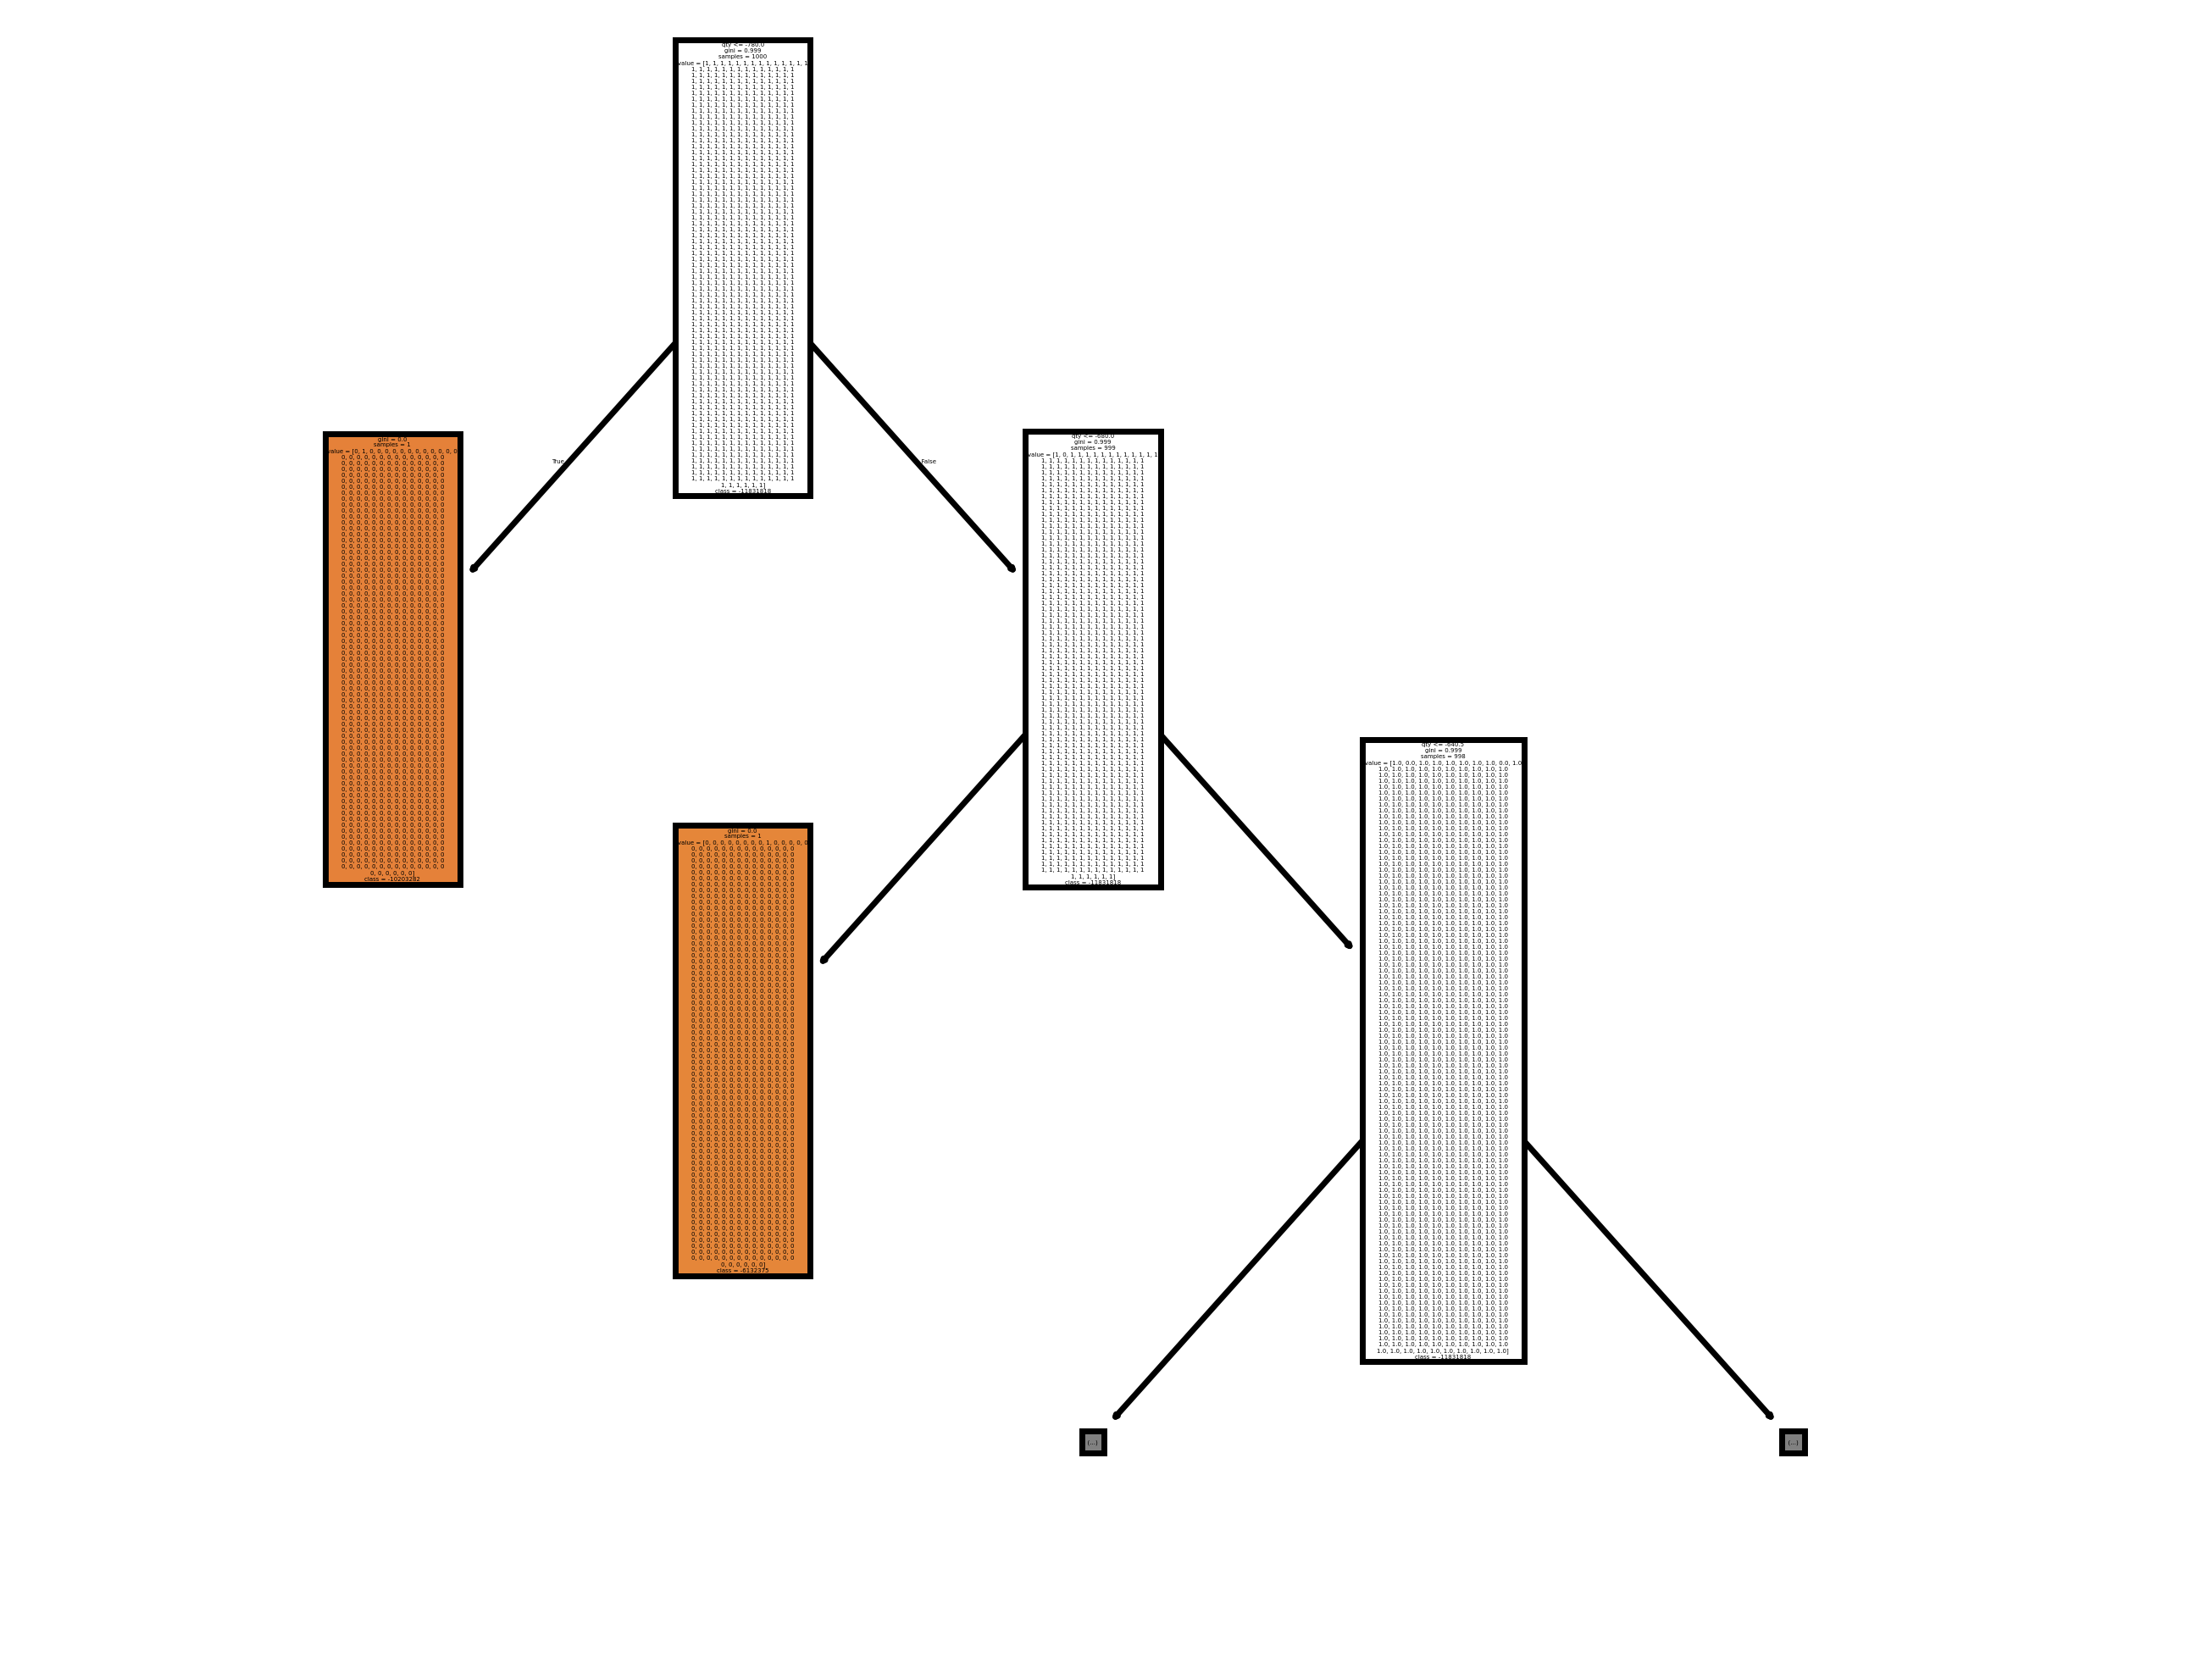

In [7]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(dpi=500)

tree.plot_tree(
    model,
    feature_names=features,
    class_names=[str(cls) for cls in model.classes_],
    filled=True,
    max_depth=2,
)

In [8]:
model.predict(
    X=[[100, 3000], [500, 120000]] # Dados escritos à mão
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1243638,  322080])

> Tentando prever dados gerados aleatóriamente pela função `rand_df_gen()` que eu defini:

In [9]:
df_teste = rand_df_gen(
    df_rows=100,
    df_cols=2,
    inf_range=(0, 50),
    sup_range=(250, 600)
)

df_teste.rename(
    columns={
        0: 'qty',
        1: 'price',
    },
    inplace=True)

df_teste['cents_price'] = df_teste['price']
df_teste['dol_price'] = df_teste['price'] / 100
df_teste['income'] = df_teste['qty'] * df_teste['price']

In [10]:
df_teste

,qty,price,cents_price,dol_price,income
0,468,25,25,0.25,11700
1,386,431,431,4.31,166366
2,86,104,104,1.04,8944
3,185,435,435,4.35,80475
4,259,229,229,2.29,59311
...,...,...,...,...,...
95,240,94,94,0.94,22560
96,83,49,49,0.49,4067
97,405,225,225,2.25,91125
98,160,315,315,3.15,50400


In [11]:
model.predict(df_teste[features])

array([ 184263,  622848,  860130, 3078279, 1663875, 2240444, 3078279,
        899232, 1243638, 3078279,  184263, 3271124, 1243638,  330536,
       1274191, 1663875,  184263, 2164648,  738969,  860130,  109411,
       3670508,  699595,  478830,  109411,  109411,  860130,  551122,
       3078279, 3078279, 3078279,  860130, 2164648,  103788,   13110,
        860130,  330536, 1663875,  860130,  103788, 3271124,  330536,
        109411, 3078279,  717504, 3078279, 3050032,  103788,  738969,
       1243638,  699595,  109411, 1243638,  384334,  699595, 3078279,
       1274191, 2485098, 3078279, 1872600,  330536, 3078279, 1243638,
       2485098, 1243638, 1243638, 2524896,  860130,  738969, 2485098,
        919425, 3078279, 3911706,   25200,  738969,   13110, 1243638,
        184263, 3078279,  899232, 2485098, 3271124,  699595,   13110,
       1663875,   13110, 1663875,  738969, 1274191,  109411, 3050032,
        384334, 5596008, 3078279,  330536,  860130,  109411,  384334,
       3078279, 1243

> Fetch dos dados Reais via API


In [14]:
import pandas as pd
import requests


response = requests.get('https://data.iowa.gov/api/v3/views/m3tr-qhgy/query.json')
data = response.json()
data

{'code': 'authentication_required',
 'error': True,
 'message': 'This request must be authenticated or have an application token'}